In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import linear_sum_assignment

# Summary of fixes:
### General
- All experiments are now done on the same datasets, generated once at the start of the notebook
- I increased the number of datapoints for the Swiss roll and Flat torus to $n=5000$
- Returned the intrinsic arclength coordinate for the Swiss-roll data cloud

### Embedding
- I only use the embedding function with the symmetric matrix. <span style="color:green">Don't need to worry about complex eigenvalues
- Corrected the markdown notation for $D_\alpha^{-1/2}$
- All orderings of eigenvectors use correct index notation.
- The function now returns a structured dictionary of all the results of the embedding. This functionality is not used extensively in this notebook

### Bandwidth selection
The main issue here was the fact that I was using the arithmetic mean rather than the geometric mean to find the optimal bandwidth.
- The grid of epsilons for bandwidth-selection now depends on the median of the smallest value in each row of the squared-distance matrix
- $\varepsilon^\star$ is now selected with geometric mean of interval. <span style="color:green">This resulted in the gradients of the linear section of the kernel mass grid being within 5% of 1 for all manifolds</span>
- Added the topology-safety test for the Swiss-roll dataset

### Geodesic vs. diffusion distance
- Used more pairs of points, removed duplicate pairs, removed self-pair
- Instead of numerical geodesic maximum, now I use the analytical maximum geodesic distance on each manifold
- Plotted seperate graphs showing the linear region and then the comparison of geodesic vs. diffusion for all points on the manifolds
- Repeated the experiment 10 times for different random seeds and presented complete results in a dataframe. Found the mean and standard deviation of the results
- Updated the discussion to explain the impact of toplolgy, curvature and multiple paths


# 1.1. Implementation of the diffusion map

### Handling complex eigenvalues

The matrix $P$ is similar to the matrix $D_\alpha^{-1/2}W^{(\alpha)}D_\alpha^{-1/2}$, which is symmetric, therefore has real eigenvalues. The eigenvectors of the symmetric matrix is related to $P$ by multiplication with $D_\alpha^{-1/2}$.

In [132]:
def embedding_real(X, epsilon=None, alpha=1, k=2):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues of S which is related to P and symmetric
    d_alpha = np.sum(W_a, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_alpha))
    S = D_inv_sqrt @ W_a @ D_inv_sqrt

    # symmetric eigendecomposition (real)
    n = S.shape[0]
    if n <= 5000:
        w, v = np.linalg.eigh(S)
    else:
        w, v = sp.sparse.linalg.eigsh(S)
    
    idx = np.argsort(w)[::-1]
    w = w[idx]
    v = v[:, idx]
    # right eigenvectors of P: phi = D^{-1/2} v
    phi = D_inv_sqrt @ v

   
    phi_k = phi[:, 1:k+1]      # skip trivial first eigenvector
    lambda_k = w[1:k+1]

    # diffusion coordinates (t = 1)
    Psi = phi_k * lambda_k      # columns scaled by eigenvalues

    res = {
        "X": X,
        "epsilon": epsilon,
        "alpha": alpha,
        "raw_degrees": q,
        "normalised_degrees": d_alpha,
        "markov_evals": w,
        "right_eigenvectors": phi,
        "diff_coordinates": Psi,
        "transition_matrix": P
    }
    return res

### Validation on the unit square

Choosing $\alpha=0$ works better for this experiment.

Since $\alpha$ helps remove the effects of uneven density of the data cloud, using it on the square dataset, sampled with uniform random variables doesn't help; it might be adding in sampling noise causing the correlation to reduce. I have kept $\alpha=1$ for the rest of the data clouds, even though they are all generated with uniform random variables. I think that the normalised affinity matrix is more useful for the next phase, where there may be highly dense regions.

In [133]:
def unit_sqare(n=2000, d=2):
    return np.random.uniform(low=0, high=1, size=(n, d))

def validate_unit_square(dm_result):
    X = dm_result["X"]
    phi = dm_result["right_eigenvectors"]

    # first two nontrivial eigenvectors
    Phi = phi[:, 1:3]

    targets = np.column_stack([
        np.cos(np.pi * X[:, 0]),
        np.cos(np.pi * X[:, 1])
    ])

    # centre and normalise columns
    Phi_n = (Phi - Phi.mean(axis=0)) / Phi.std(axis=0)
    T_n = (targets - targets.mean(axis=0)) / targets.std(axis=0)

    # absolute correlations allow sign ambiguity
    C = np.abs(np.corrcoef(Phi_n.T, T_n.T)[:2, 2:])

    # best permutation
    rows, cols = linear_sum_assignment(-C)

    return {
        "correlation_matrix": C,
        "best_matching": list(zip(rows, cols)),
        "matched_correlations": C[rows, cols],
        "mean_matched_correlation": C[rows, cols].mean()
    }

In [134]:
X = unit_sqare(n=3000)

In [135]:
unit_square_dm = embedding_real(X, epsilon=0.05, alpha=0)
validation = validate_unit_square(unit_square_dm)
print(validation["correlation_matrix"])
print(validation["mean_matched_correlation"])

[[0.94670972 0.33288793]
 [0.32304892 0.94153505]]
0.9441223885449457


In [136]:
unit_square_dm = embedding_real(X, epsilon=0.05, alpha=1)
validation = validate_unit_square(unit_square_dm)
print(validation["correlation_matrix"])
print(validation["mean_matched_correlation"])

[[0.9772453  0.22266808]
 [0.20542844 0.97567039]]
0.976457844284394


# 1.2. Generation of manifolds
## Swiss Roll dataset

In [137]:
np.random.seed(0)

def swiss_roll(n: int = 2000):
    theta = np.random.uniform(low=3*np.pi/2, high=9*np.pi/2, size=n)
    z = np.random.uniform(low=0, high=20, size=n)

    x, y = theta*np.cos(theta), theta*np.sin(theta)

    X = np.stack((x,y,z), axis=1)

    # Intrinsic arclength coordinate
    S = 1/2 * (theta * np.sqrt(1 + theta**2) + np.arcsinh(theta))

    intrinsic = np.stack((S, z), axis=1)

    return X, intrinsic

X_swiss_roll, I_swiss_roll = swiss_roll(5000)

## Flat torus in $\mathbb{R}^4$

In [138]:
np.random.seed(0)

def flat_torus(n: int = 2000):
    theta, phi = np.random.uniform(low=0, high=np.pi * 2, size=n), np.random.uniform(low=0, high=np.pi * 2, size=n)
    X = np.stack((np.cos(theta), np.sin(theta), np.cos(phi), np.sin(phi)), axis=1)
    
    intrinsic = np.stack((theta, phi), axis=1)
    return X, intrinsic

X_torus, I_torus = flat_torus(5000)

## Two-sphere

In [139]:
np.random.seed(0)

def two_sphere(n: int = 2000):
    u, v = np.random.uniform(low=0, high=1, size=n), np.random.uniform(low=0, high=1, size=n)
    theta = np.arccos(1 - 2*u)
    phi = 2 * np.pi * v
    X = np.stack((np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)), axis=1)

    intrinsic = np.stack((theta, phi), axis=1)
    return X, intrinsic

X_sphere, I_sphere = two_sphere(5000)

# 1.3. Bandwidth Selection

Total kernel mass: $T(\varepsilon) = \sum_{i,j=1}^n\text{exp}( − \|x_i − x_j\|^2 / \varepsilon)$

In [140]:
def kernel_mass(D, eps_grid):
    '''
    Returns a list of kernel masses for each bandwidth epsilon
    given a distance matrix and an array of bandwidths

    args:
        D: matrix of squared distances Dij = ||xi - xj||^2
        eps_grid: array of bandwidth values
    returns:
        T_eps: List of kernel masses for each bandwidth
    '''

    n = D.shape[0]
    T_eps = []
    T_off_eps = []

    for epsilon in eps_grid:
        T = np.sum(np.exp(-D / epsilon))
        T_eps.append(T)
        # Diagonal entries only add 1*n, so T_off is T-n
        T_off_eps.append(T - n)
        
    return T_eps, T_off_eps

In [141]:
def plot_kernel_mass(X, title="Kernel Mass Plot", plot=True, ax=None):
    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)

    ### FIX: Found median of minimal distance of each row
    ### this is used to set the lower end of the grid
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    d_min = np.median(np.min(D_no_diag, axis=1))
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_min) - 2,
        np.log10(d_med) + 2,
        50
    )

    T_eps, T_off_eps = kernel_mass(D, eps_grid)

    log_eps = np.log(eps_grid)
    log_T = np.log(T_eps)
    slope = np.gradient(log_T, log_eps)

    if plot:
        if ax is not None:
            ax.loglog(eps_grid, T_eps)
            #ax.loglog(eps_grid, T_off_eps)
            ax.set_title(title)
            ax.set_xlabel(r"$\varepsilon$")
            ax.set_ylabel(r"$T(\varepsilon)$")
            ax.legend()
        else:
            fig, (ax1, ax2) = plt.subplots(1,2)
            # Plotting the kernel mass plot
            ax1.loglog(eps_grid, T_eps)
            ax1.set_title(title)
            ax1.set_xlabel(r"$\varepsilon$")
            ax1.set_ylabel(r"$T(\varepsilon)$")
            ax1.grid(True, axis='x', which='both', ls='-')
            # Plotting the gradient
            ax2.semilogx(eps_grid, slope)
            ax2.axhline(1, linestyle="--", label="Expected slope k/2 = 1")
            ax2.set_xlabel(r"$\varepsilon$")
            ax2.set_ylabel("local slope")
            ax2.set_title("Gradient of Kernel Mass Plot")
            ax2.grid(True, axis='x', which='both', ls='-')
            fig.set_figheight(5)
            fig.set_figwidth(14)
            plt.legend()
            plt.show()

### Plotting $\log T(\varepsilon)$ vs. $\log \varepsilon$

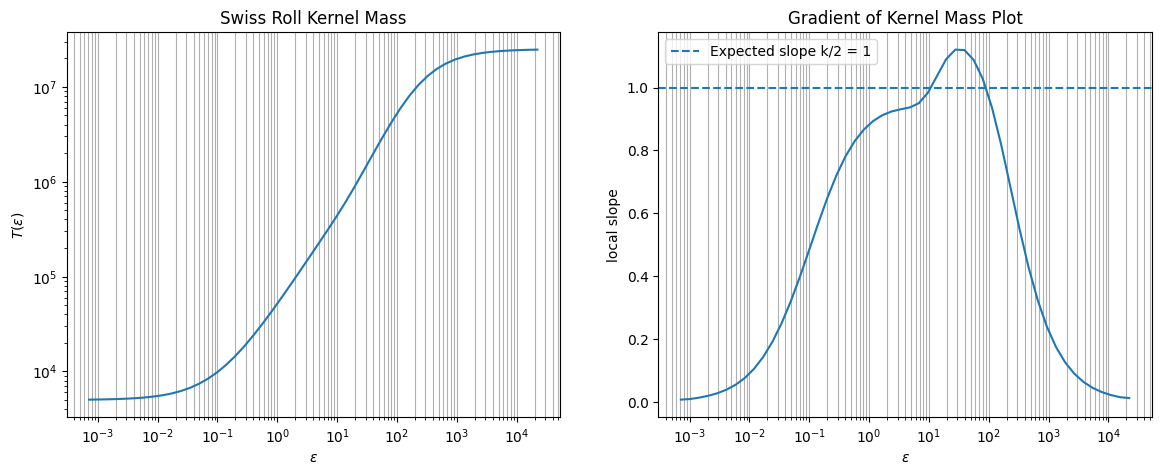

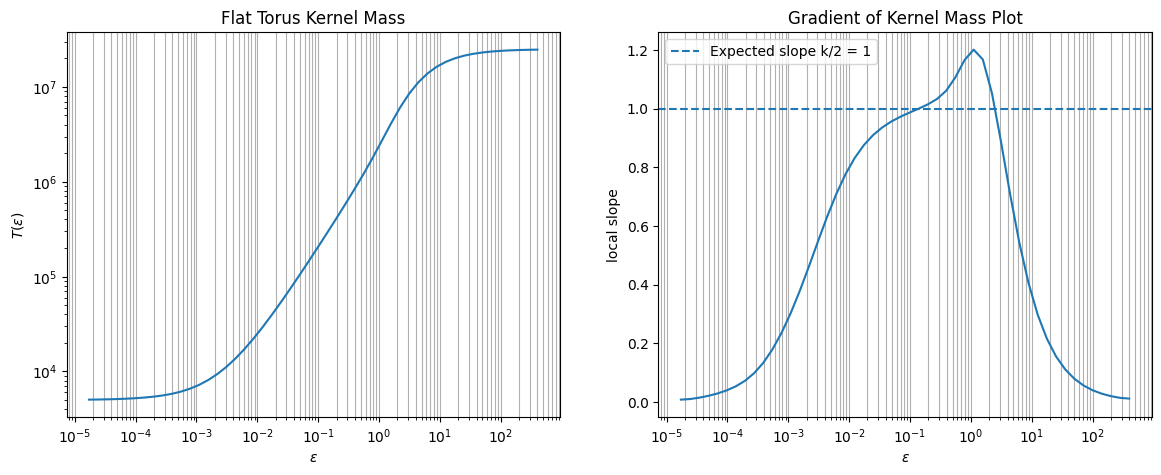

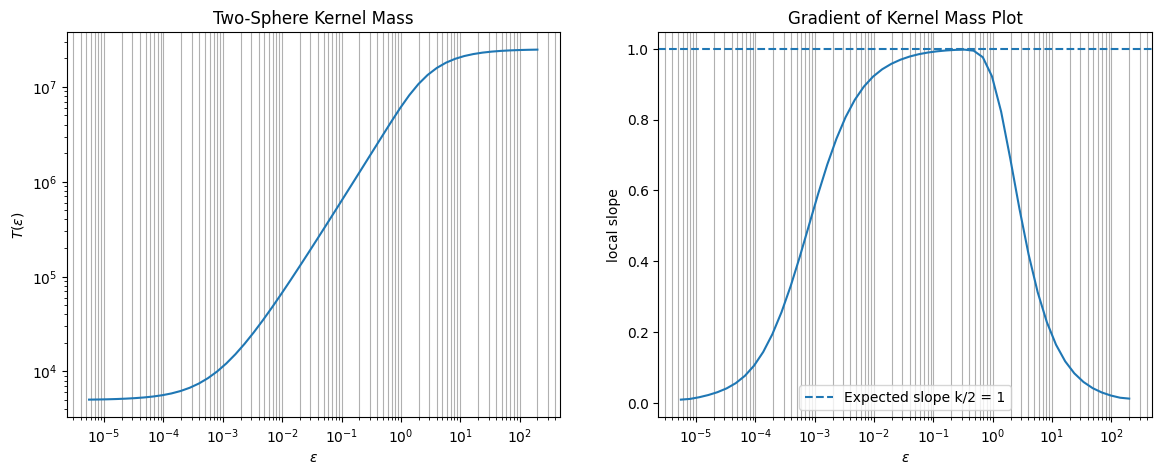

In [142]:
plot_kernel_mass(X_swiss_roll, title="Swiss Roll Kernel Mass")
plot_kernel_mass(X_torus, title="Flat Torus Kernel Mass")
plot_kernel_mass(X_sphere, title="Two-Sphere Kernel Mass")

### Visual analysis

- Swiss roll: $\varepsilon \in [0.2, 100]$
- Flat torus: $\varepsilon \in [0.03, 0.6]$
- Two sphere: $\varepsilon \in [0.05, 0.5]$

### Fitting slopes for each linear regime

In [143]:
def log_polyfit(x, y, deg=1):
    '''
    Returns the gradient and intercept of the linear 
    approximation of (log(x), log(y))
    '''
    log_x = np.log10(x)
    log_y = np.log10(y)

    m, c = np.polyfit(log_x, log_y, deg=deg)

    return m, c

In [144]:

# Linear regions identified visually
eps_sr_reg = [0.2, 100]
eps_ft_reg = [0.03, 0.6]
eps_ts_reg = [0.05, 0.5]


# Swiss roll
# region of epsilon grid for linear behaviour
eps_grid_sr = np.logspace(np.log10(eps_sr_reg[0]), np.log10(eps_sr_reg[1]), 40)
# Computing the kernel mass for this region
d_sr = sp.spatial.distance.pdist(X_swiss_roll)**2
D_sr = sp.spatial.distance.squareform(d_sr)
T_eps_sr, _ = kernel_mass(D_sr, eps_grid_sr)
# Computing the slope of the linear region
m_sr, c_sr = log_polyfit(eps_grid_sr, T_eps_sr)
print(f'Linear regime Gradient for swiss roll: {m_sr:.2f}')


# Flat torus
eps_grid_ft = np.logspace(np.log10(eps_ft_reg[0]), np.log10(eps_ft_reg[1]), 40)
d_ft = sp.spatial.distance.pdist(X_torus)**2
D_ft = sp.spatial.distance.squareform(d_ft)
T_eps_ft, _ = kernel_mass(D_ft, eps_grid_ft)
m_ft, c_ft = log_polyfit(eps_grid_ft, T_eps_ft)
print(f'Linear regime Gradient for flat torus: {m_ft:.2f}')

# Two-sphere
eps_grid_ts = np.logspace(np.log10(eps_ts_reg[0]), np.log10(eps_ts_reg[1]), 40)
d_ts = sp.spatial.distance.pdist(X_sphere)**2
D_ts = sp.spatial.distance.squareform(d_ts)
T_eps_ts, _ = kernel_mass(D_ts, eps_grid_ts)
m_ts, c_ts = log_polyfit(eps_grid_ts, T_eps_ts)
print(f'Linear regime Gradient for two-sphere: {m_ts:.2f}')


Linear regime Gradient for swiss roll: 0.96
Linear regime Gradient for flat torus: 1.00
Linear regime Gradient for two-sphere: 0.99


In [145]:
def plot_kernel_mass_2(X, title="Kernel Mass Annotated Plot", ax=None, linear_region=None, fit_line=True):
    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)

    ### FIX: Found median of minimal distance of each row
    ### this is used to set the lower end of the grid
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    d_min = np.median(np.min(D_no_diag, axis=1))
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_min) - 2,
        np.log10(d_med) + 2,
        50
    )

    T_eps, _ = kernel_mass(D, eps_grid)

    if linear_region is not None:
        eps_lo, eps_hi = linear_region
        mask = (eps_grid >= eps_lo) & (eps_grid <= eps_hi)
        eps_fit = eps_grid[mask]
        T_fit = np.asarray(T_eps)[mask]
        m, c = log_polyfit(eps_fit, T_fit)
    else:
        m, c = log_polyfit(eps_grid, T_eps)
        eps_lo, eps_hi = None, None

    if ax is not None:
        ax.loglog(eps_grid, T_eps, label="kernel mass")
        if linear_region is not None:
            ax.axvspan(eps_lo, eps_hi, color="tab:orange", alpha=0.18, label="linear window")
        if fit_line:
            eps_line = np.linspace(eps_grid.min(), eps_grid.max(), 300)
            T_line = 10 ** (m * np.log10(eps_line) + c)
            ax.loglog(eps_line, T_line, "--", color="tab:red", label=f"fit: m={m:.2f}")
        ax.set_title(title)
        ax.set_xlabel(r"$\varepsilon$")
        ax.set_ylabel(r"$T(\varepsilon)$")
        ax.legend()
    else:
        plt.loglog(eps_grid, T_eps, label="kernel mass")
        if linear_region is not None:
            plt.axvspan(eps_lo, eps_hi, color="tab:orange", alpha=0.18, label="linear window")
        if fit_line:
            eps_line = np.linspace(eps_grid.min(), eps_grid.max(), 300)
            T_line = 10 ** (m * np.log10(eps_line) + c)
            plt.loglog(eps_line, T_line, "--", color="tab:red", label=f"fit: m={m:.2f}")
        plt.title(title)
        plt.xlabel(r"$\varepsilon$")
        plt.ylabel(r"$T(\varepsilon)$")
        plt.legend()
        plt.show()

### Annotated kernel mass plots

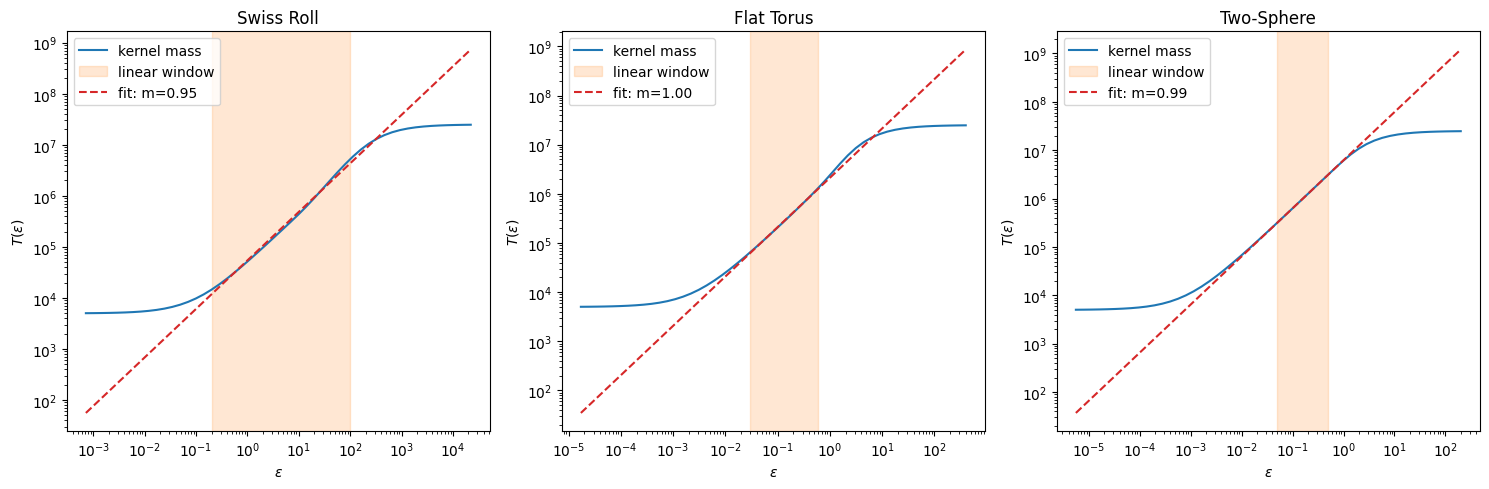

In [146]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figheight(5)
fig.set_figwidth(15)

plot_kernel_mass_2(X_swiss_roll, title="Swiss Roll", ax=ax1, linear_region=eps_sr_reg)
plot_kernel_mass_2(X_torus, title="Flat Torus", ax=ax2, linear_region=eps_ft_reg)
plot_kernel_mass_2(X_sphere, title="Two-Sphere", ax=ax3, linear_region=eps_ts_reg)

fig.tight_layout()

### Selecting bandwidth by $\varepsilon^\star = \sqrt{\varepsilon_\text{min} \varepsilon_\text{max}}$

In [147]:
EPS_SR = np.sqrt(eps_sr_reg[0]*eps_sr_reg[1])
EPS_FT = np.sqrt(eps_ft_reg[0]*eps_ft_reg[1])
EPS_TS = np.sqrt(eps_ts_reg[0]*eps_ts_reg[1])

In [148]:
headers = ["Data Cloud", "Linear eps Grid", "Linear Approximation Error", "eps*"]
rows = [
    ["Swiss Roll", str(eps_sr_reg), f"{abs(1-m_sr)*100:.2f}%", f"{EPS_SR:.2f}"],
    ["Flat Torus", str(eps_ft_reg), f"{abs(1-m_ft)*100:.2f}%", f"{EPS_FT:.2f}"],
    ["Two Sphere", str(eps_ts_reg), f"{abs(1-m_ts)*100:.2f}%", f"{EPS_TS:.2f}"]
]

widths = [14, 18, 28, 6]
print("+" + "+".join("-" * (w + 2) for w in widths) + "+")
header_str = " | ".join(f"{h:<{widths[i]}}" for i, h in enumerate(headers))
print(f"| {header_str} |")
print("+" + "+".join("-" * (w + 2) for w in widths) + "+")
for row in rows:
    row_str = " | ".join(f"{item:<{widths[i]}}" for i, item in enumerate(row))
    print(f"| {row_str} |")
print("+" + "+".join("-" * (w + 2) for w in widths) + "+")


+----------------+--------------------+------------------------------+--------+
| Data Cloud     | Linear eps Grid    | Linear Approximation Error   | eps*   |
+----------------+--------------------+------------------------------+--------+
| Swiss Roll     | [0.2, 100]         | 4.30%                        | 4.47   |
| Flat Torus     | [0.03, 0.6]        | 0.17%                        | 0.13   |
| Two Sphere     | [0.05, 0.5]        | 0.57%                        | 0.16   |
+----------------+--------------------+------------------------------+--------+


### Bandwidth results table
| Data Cloud | Linear $\varepsilon$ Grid | Linear Approximation Error | $\varepsilon^*$ |
| :--- | :---: | :---: | :---: |
| Swiss Roll | $[0.2, 100]$ | $4\%$ | $4.47$ |
| Flat Torus | $[0.03, 0.6]$ | $0\%$ | $0.13$ |
| Two Sphere | $[0.05, 0.5]$ | $1\%$ | $0.16$ |

<span style="color:green">Validation evidence: the linear approximation error is less than 5% for all manifolds (without any biased selection of intervals)

### Swiss-roll topology-safety test

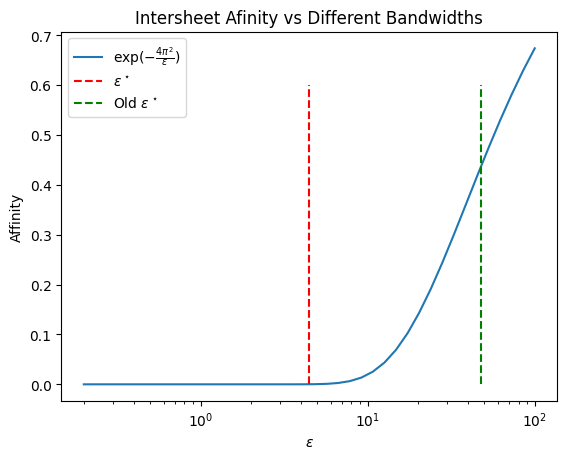

In [149]:
sr_eps_space = np.logspace(np.log10(eps_sr_reg[0]), np.log10(eps_sr_reg[1]), 40)

intersheet_affinity = np.exp(-(4*np.pi**2/sr_eps_space))

plt.semilogx(sr_eps_space, intersheet_affinity, label=r"$\exp(-\frac{4\pi^2}{\varepsilon})$")
plt.vlines(x=EPS_SR, ymin=0, ymax=0.6, colors='r', linestyles='--', label=r"$\varepsilon^\star$")
plt.vlines(x=48, ymin=0, ymax=0.6, colors='g', linestyles='--', label=r"Old $\varepsilon^\star$")
plt.title("Intersheet Afinity vs Different Bandwidths")
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Affinity")
plt.legend()
plt.show()

Clearly the selected value of $\varepsilon^\star$ is small enough to not be strongly impacted by cross sheet interactions. My previous choice of $\varepsilon^\star=48$ was too big, and therefore the transition matrix included too much information from adjacent sheets, this would have impacted the emedding. kNN is therefore not required here.

# 1.4. Spectral gap analysis

In [150]:
# The embedding function can return the eigenvalues/vectors
# so I do the embedding here to avoid building the big matrices
# multiple times

swiss_roll_dm = embedding_real(X_swiss_roll, epsilon=EPS_SR, k=5)
flat_torus_dm = embedding_real(X_torus, epsilon=EPS_FT, k=5)
two_sphere_dm = embedding_real(X_sphere, epsilon=EPS_TS, k=5)

Psi_sr, P_sr, w_sr = (
    swiss_roll_dm["diff_coordinates"],
    swiss_roll_dm["transition_matrix"],
    swiss_roll_dm["markov_evals"],
)

Psi_ft, P_ft, w_ft = (
    flat_torus_dm["diff_coordinates"],
    flat_torus_dm["transition_matrix"],
    flat_torus_dm["markov_evals"],
)

Psi_ts, P_ts, w_ts = (
    two_sphere_dm["diff_coordinates"],
    two_sphere_dm["transition_matrix"],
    two_sphere_dm["markov_evals"],
)

In [151]:
eigenvalues = {
    "Swiss roll": w_sr,
    "Flat torus": w_ft,
    "Two-sphere": w_ts
}

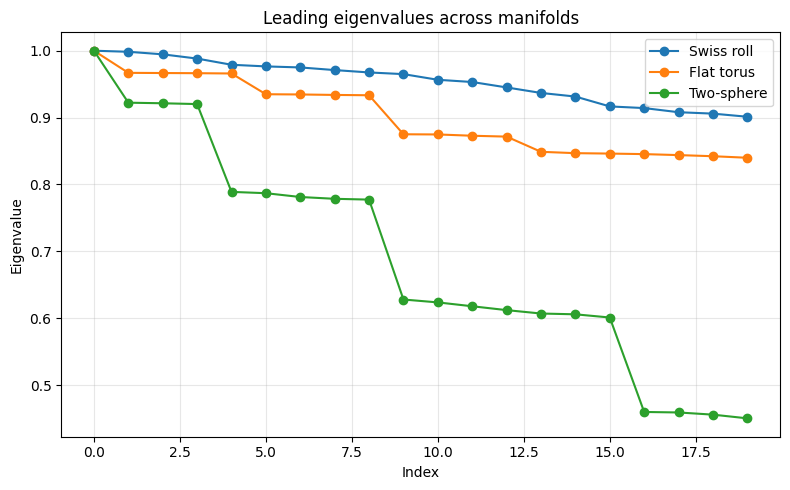

In [152]:
plt.figure(figsize=(8, 5))
for name, w in eigenvalues.items():
    plt.plot(w[:20], marker='o', label=name)
plt.title('Leading eigenvalues across manifolds')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

- For the two-sphere, we can see that for $\mathcal{l}=1$ we have 3 ($2\mathcal{l}+1$) eigenvalues of very similar values, for $\mathcal{l}=2$ we have 5, etc. This checks out with what you said.

- For the flat torus the eigenvalues seem to be grouped into groups of 4

- The Swiss roll shows a very flat spectrum

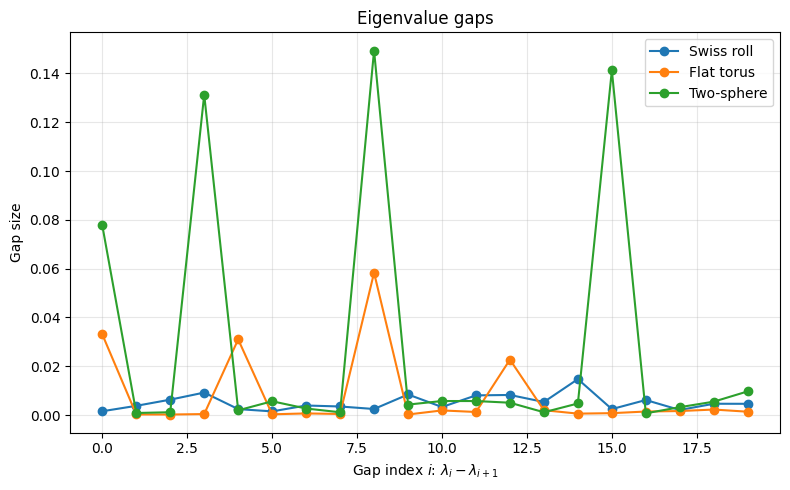

In [153]:
plt.figure(figsize=(8, 5))

for name, w in eigenvalues.items():
    gaps = w[:-1] - w[1:]
    gaps = gaps[:20]
    plt.plot(np.arange(len(gaps)), gaps, marker='o', label=name)

plt.title("Eigenvalue gaps")
plt.xlabel(r"Gap index $i$: $\lambda_i - \lambda_{i+1}$")
plt.ylabel("Gap size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# <span style="color:red">TALK ABOUT THESE GRAPHS

# 1.5. Recovery of geodesic distance

In [154]:
def create_pairs(n_samples, n_pairs=500):
    a = np.random.choice(n_samples, size=n_pairs)
    b = np.random.choice(n_samples, size=n_pairs)

    pairs = np.stack((a, b), axis=1)

    # remove self-pairs
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]

    # remove duplicates and reverse duplicates
    pairs = np.sort(pairs, axis=1)
    pairs = np.unique(pairs, axis=0)

    return pairs

np.random.seed(0)
n_samples = X_torus.shape[0]
pairs = create_pairs(n_samples, n_pairs=2500)

In [155]:
def diffusion_distance(Psi, pairs):
    '''
    Get the distance between each pair of embedded points
    following the equation in pdf
    '''
    diffs = Psi[pairs[:, 0]] - Psi[pairs[:, 1]]
    return np.linalg.norm(diffs, axis=1)
    
def analytic_dist_sphere(X, pairs):
    '''
    Get the distance between each point on the two-sphere
    using analytic solution
    '''
    dots = np.sum(X[pairs[:, 0]] * X[pairs[:, 1]], axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    return np.arccos(dots)

def analytic_dist_torus(theta, phi, pairs):
    '''
    Get the distance between each point on the flat torus
    using the geodesic equation given in the notes
    
    '''
    t1 = theta[pairs[:, 0]]
    t2 = theta[pairs[:, 1]]

    p1 = phi[pairs[:, 0]]
    p2 = phi[pairs[:, 1]]

    dt = np.abs(t1 - t2)
    dp = np.abs(p1 - p2)

    dt = np.minimum(dt, 2*np.pi - dt)
    dp = np.minimum(dp, 2*np.pi - dp)

    return np.sqrt(dt**2 + dp**2)

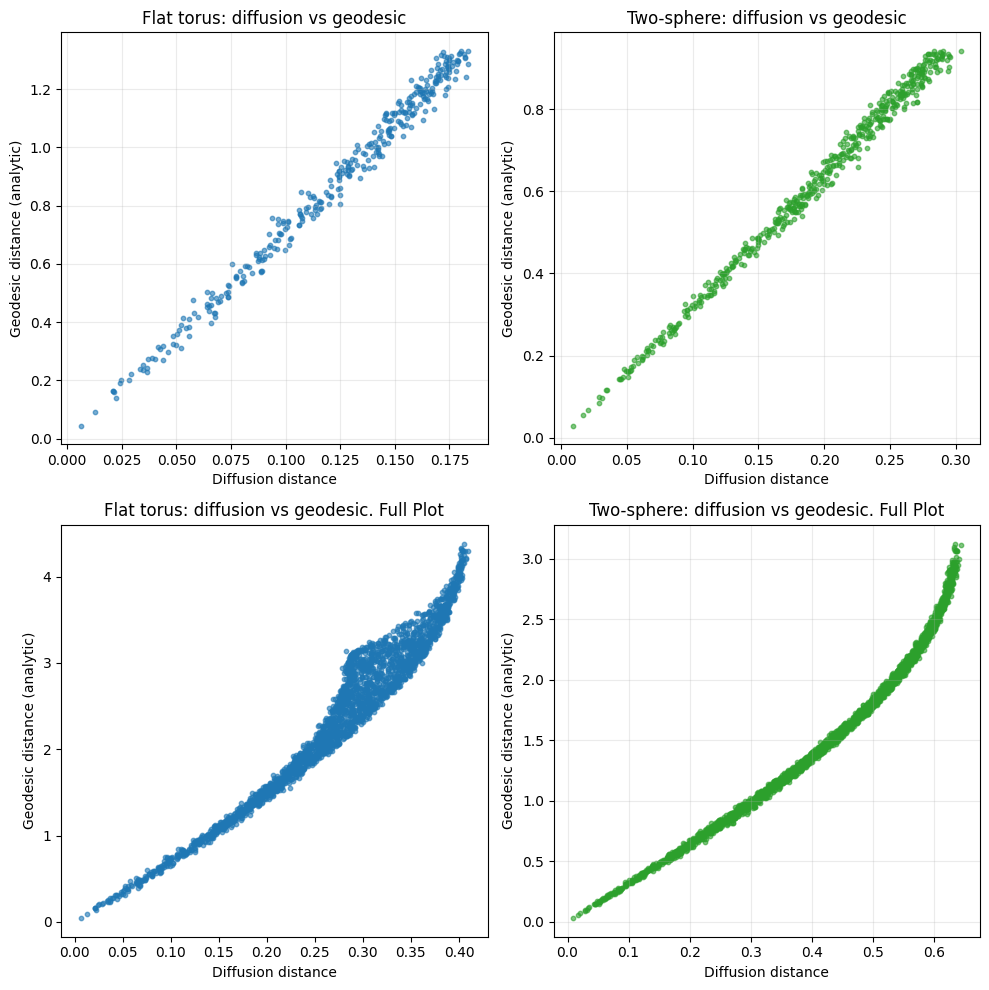

In [156]:
# Extracting theta and phi from the intrinsic dimension for the flat torus
X_torus, theta_ft, phi_ft = X_torus, I_torus[:, 0], I_torus[:, 1]

# Running the embedding function for k=5 means
# that I can investigate different values of k
# without rerunning embedding
r_ft = 4
r_ts = 3

Psi_ft_k = Psi_ft[:, :r_ft]
Psi_ts_k = Psi_ts[:, :r_ts]

# Embedding distances
D_ft = diffusion_distance(Psi_ft_k, pairs)
D_ts = diffusion_distance(Psi_ts_k, pairs)

# Analytic geodesic distances
d_ft = analytic_dist_torus(theta_ft, phi_ft, pairs)
d_ts = analytic_dist_sphere(X_sphere, pairs)

# Maximum goedisic distance
d_ft_max = np.pi * np.sqrt(2)
d_ts_max = np.pi

# Get rid of all points which are too far apart
mask_ft = d_ft < 0.3*d_ft_max
mask_ts = d_ts < 0.3*d_ts_max

fig, (ax1, ax2) = plt.subplots(2,2)
fig.set_figheight(10)
fig.set_figwidth(10)

# Flat torus: scatter diffusion vs analytic geodesic (subset)
x1 = D_ft[mask_ft].flatten()
y1 = d_ft[mask_ft].flatten()
ax1[0].scatter(x1, y1, s=10, alpha=0.6, color='tab:blue')
ax1[0].set_title('Flat torus: diffusion vs geodesic')
ax1[0].set_xlabel('Diffusion distance')
ax1[0].set_ylabel('Geodesic distance (analytic)')
ax1[0].grid(alpha=0.25)


# Two-sphere: scatter diffusion vs analytic geodesic (subset)
x2 = D_ts[mask_ts].flatten()
y2 = d_ts[mask_ts].flatten()
ax1[1].scatter(x2, y2, s=10, alpha=0.6, color='tab:green')
ax1[1].set_title('Two-sphere: diffusion vs geodesic')
ax1[1].set_xlabel('Diffusion distance')
ax1[1].set_ylabel('Geodesic distance (analytic)')
ax1[1].grid(alpha=0.25)


### Full plot
# Flat torus: scatter diffusion vs analytic geodesic
x1 = D_ft.flatten()
y1 = d_ft.flatten()
ax2[0].scatter(x1, y1, s=10, alpha=0.6, color='tab:blue')
ax2[0].set_title('Flat torus: diffusion vs geodesic. Full Plot')
ax2[0].set_xlabel('Diffusion distance')
ax2[0].set_ylabel('Geodesic distance (analytic)')
ax1[0].grid(alpha=0.25)

# Two-sphere: scatter diffusion vs analytic geodesic
x2 = D_ts.flatten()
y2 = d_ts.flatten()
ax2[1].scatter(x2, y2, s=10, alpha=0.6, color='tab:green')
ax2[1].set_title('Two-sphere: diffusion vs geodesic. Full Plot')
ax2[1].set_xlabel('Diffusion distance')
ax2[1].set_ylabel('Geodesic distance (analytic)')
ax2[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()


In [157]:
def analyze_embedding(name, Psi, geo_func, d_max=None, max_k=None):
    rows = []
    ncols = Psi.shape[1]
    maxk = ncols if max_k is None else min(ncols, max_k)
    for k in range(1, maxk + 1):
        D_emb = diffusion_distance(Psi[:, :k], pairs)
        d_geo = geo_func()
        
        if d_max is None:
            d_max = max(d_geo)

        mask = d_geo < 0.3 * d_max

        D_emb = np.asarray(D_emb)[mask].flatten()
        d_geo = np.asarray(d_geo)[mask].flatten()

        mask = ~np.isnan(D_emb) & ~np.isnan(d_geo)
        if np.sum(mask) < 2:
            slope = np.nan
            r2 = np.nan
        else:
            res = sp.stats.linregress(D_emb[mask], d_geo[mask])
            slope = res.slope
            r2 = res.rvalue ** 2

        rows.append({'manifold': name, 'k': k, 'slope': slope, 'R2': r2, 'n_pairs': int(np.sum(mask))})
    
    return rows


if 'Psi_ft' in globals():
    ft_rows = analyze_embedding('Flat torus', Psi_ft, lambda: analytic_dist_torus(theta_ft, phi_ft, pairs), d_max=np.pi*np.sqrt(2))
if 'Psi_ts' in globals():
    ts_rows = analyze_embedding('Two-sphere', Psi_ts, lambda: analytic_dist_sphere(X_sphere, pairs), d_max=np.pi)

rows = ft_rows + ts_rows
df = pd.DataFrame(rows)
display(df)


,manifold,k,slope,R2,n_pairs
0,Flat torus,1,3.834754,0.221770,342
1,Flat torus,2,4.942491,0.435535,342
2,Flat torus,3,5.710091,0.642640,342
3,Flat torus,4,7.376721,0.988750,342
4,Flat torus,5,5.377828,0.820995,342
5,Two-sphere,1,1.627003,0.242852,514
6,Two-sphere,2,2.377502,0.579547,514
7,Two-sphere,3,3.251407,0.993207,514
8,Two-sphere,4,1.969492,0.731694,514
9,Two-sphere,5,1.676534,0.737720,514


### Repeating for multiple different seeds

In [158]:
def analyze_embedding_single(name, Psi, geo_func, d_max=None):
    '''
    Compares the diffusion distance with the geodesic distance
    for a single diffusion-map embedding for a data cloud
    '''
    rows = []

    D_emb = diffusion_distance(Psi, pairs)
    d_geo = geo_func()
    
    if d_max is None:
        d_max = max(d_geo)

    mask = d_geo < 0.3 * d_max

    D_emb = np.asarray(D_emb)[mask].flatten()
    d_geo = np.asarray(d_geo)[mask].flatten()

    mask = ~np.isnan(D_emb) & ~np.isnan(d_geo)
    if np.sum(mask) < 2:
        slope = np.nan
        intercept = np.nan
        r2 = np.nan
    else:
        res = sp.stats.linregress(D_emb[mask], d_geo[mask])
        slope = res.slope
        intercept = res.intercept
        r2 = res.rvalue ** 2

    rows.append({'manifold': name, 'slope': slope, 'intercept': intercept, 'R2': r2, 'n_pairs': int(np.sum(mask))})
    
    return rows

In [163]:
res = []
d_max_ft = np.pi*np.sqrt(2)
d_max_ts = np.pi
n_samples = 5000
n_pairs = 2500

for i in range(10):
    np.random.seed(i)
    # Produce data clouds
    X_torus, I_torus = flat_torus(n_samples)
    X_sphere, I_sphere = two_sphere(n_samples)

    # Extract intrinsic coordinates for the flat-torus data cloud
    theta_ft = I_torus[:, 0]
    phi_ft = I_torus[:, 1]

    # Form embedding
    Psi_ft = embedding_real(X_torus, epsilon=EPS_FT, k=4)["diff_coordinates"]
    Psi_ts = embedding_real(X_sphere, epsilon=EPS_TS, k=3)["diff_coordinates"]

    # Get pairs
    pairs = create_pairs(n_samples, n_pairs)

    ft_rows = analyze_embedding_single('Flat torus', Psi_ft, lambda: analytic_dist_torus(theta_ft, phi_ft, pairs), d_max=d_max_ft)
    ts_rows = analyze_embedding_single('Two-sphere', Psi_ts, lambda: analytic_dist_sphere(X_sphere, pairs), d_max=d_max_ts)

    res += ft_rows
    res += ts_rows

df = pd.DataFrame(res)
df.set_index(keys="manifold", inplace=True)
df.sort_index(inplace=True)

### Results 

In [164]:
df.groupby("manifold").mean()

,slope,intercept,R2,n_pairs
manifold,,,,
Flat torus,7.314786,-0.012395,0.985213,356.5
Two-sphere,3.247168,-0.005211,0.991605,507.9


In [167]:
df.groupby("manifold").std()

,slope,intercept,R2,n_pairs
manifold,,,,
Flat torus,0.049875,0.006693,0.002538,18.349992
Two-sphere,0.015292,0.002761,0.001410,12.948187


In [166]:
df

,slope,intercept,R2,n_pairs
manifold,,,,
Flat torus,7.392103,-0.020906,0.985685,354
Flat torus,7.317005,-0.014019,0.982392,366
Flat torus,7.279591,-0.006073,0.982358,350
Flat torus,7.293556,-0.009455,0.989044,345
Flat torus,7.381671,-0.019249,0.986590,363
Flat torus,7.241316,-0.005425,0.985895,369
Flat torus,7.333319,-0.013614,0.989281,375
Flat torus,7.281735,-0.007068,0.984190,328
Flat torus,7.272513,-0.005457,0.983492,331


The quantity $D_t(x,y)$ measure the difference between heat distributions on the manifold at time t originating from $x$ and $y$. For small geodesic distances $D_t(x, y) \approx Cd_g(x,y)$, but there is no reason that this relationship should hold globally. At larger distances, the heat distribution is impacted by more than just the shortest path between two points, it is impacted by toplology, curvature, and the multiple paths between points. For far away points, these factors start to have a larger and larger impact on the heat distributions, causing the relationship between the geodesic distance and diffusion distance to deteriorate. Additionally, the truncated diffusion-map embedding retains only the leading eigenfunctions which smooths the representation. This all leads to the devations in the relationship between $D_t$ and $d_g$ at large distances.